# **Problem Statement**

In today's fast-paced e-commerce landscape, ensuring high customer satisfaction is crucial for business success. The goal of this project is to predict the **Customer Satisfaction Score (CSAT)** based on various order-related, shipment, and service interaction features. By leveraging historical customer support data, we aim to build a machine learning model that can accurately classify whether a customer is **satisfied or dissatisfied** with their shopping experience. This will help e-commerce platforms **proactively identify dissatisfaction drivers**, improve logistics and service quality, and ultimately enhance customer retention. We will follow a structured pipeline involving **EDA, preprocessing, feature engineering, model training, evaluation, and interpretation** to build a robust and interpretable predictive system.


# **Mount Google Drive**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

# **Load and Inspect Dataset**

This step involves reading the dataset into memory and performing initial checks using .shape, .info(), and .describe() to understand its structure, data types, and basic statistics. It sets the foundation for all downstream processing.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/DeepCSAT/eCommerce_Customer_support_data.csv')
df.head()


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [ ]:
# Check dataset shape and structure
print("Shape:", df.shape)
df.info()


Shape: (85907, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Age

In [ ]:
# View descriptive statistics for all columns
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unique id,85907,85907,07c7a878-0d5a-42e0-97ef-de59abec0238,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_name,85907,3,Inbound,68142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,85907,12,Returns,44097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-category,85907,57,Reverse Pickup Enquiry,22389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Remarks,28742,18231,Good,1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_id,67675,67675,3230db30-f8da-4c44-8636-ec76d1d3d4f3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date_time,17214,13766,09/08/2023 11:55,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_reported at,85907,30923,13/08/2023 10:40,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_responded,85907,30262,28/08/2023 00:00,3378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Survey_response_Date,85907,31,28-Aug-23,3452,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Exploratory Data Analysis**

This section involves summarizing and visualizing the dataset to identify patterns, trends, anomalies, and class distributions. EDA informs feature engineering decisions and highlights data quality issues before modeling.

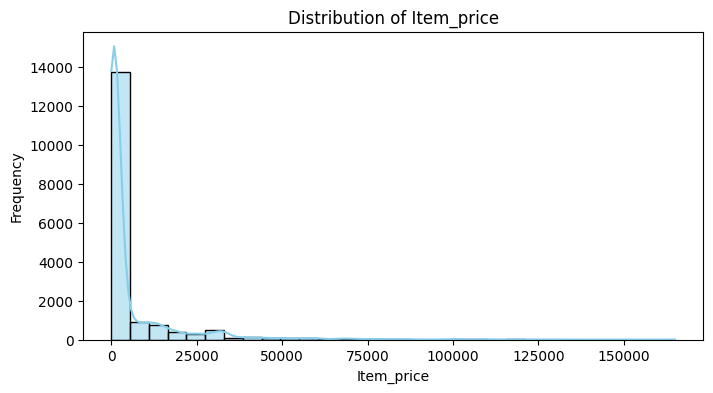

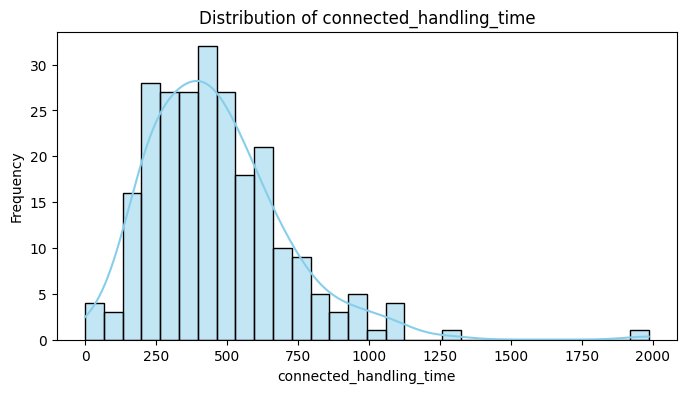

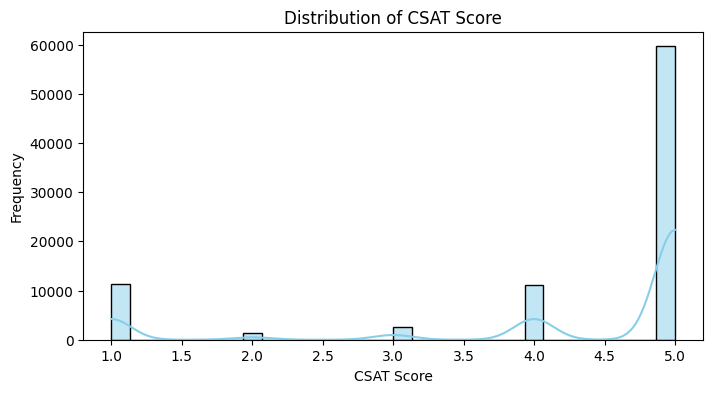

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define numeric_df from df
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Get numeric column names
numeric_cols = numeric_df.columns

# Step 3: Plot histograms
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


# **Distribution of Key Numeric Features**

1. **Item_price** is heavily right-skewed, with most prices low and a few extreme outliers — a candidate for transformation.

2. **Connected_handling_time** is roughly normal with a slight skew, indicating typical durations with some longer cases.

3. **CSAT Score** is highly imbalanced, with a strong peak at score 5, suggesting customer satisfaction is generally high but class imbalance must be addressed during modeling.

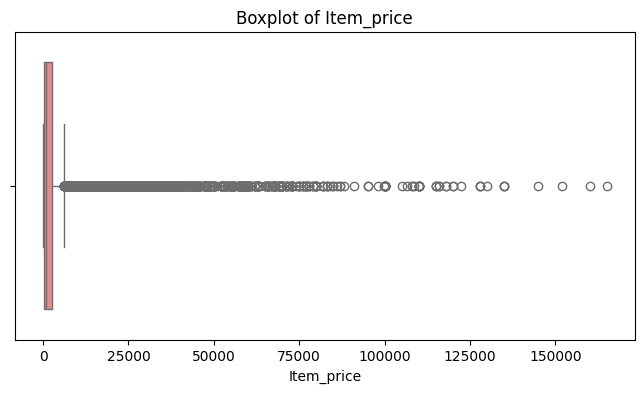

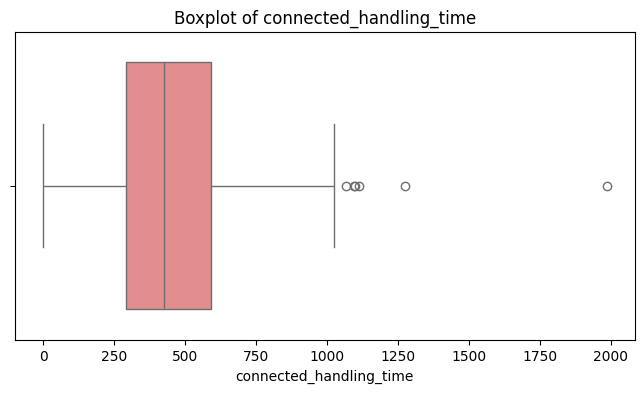

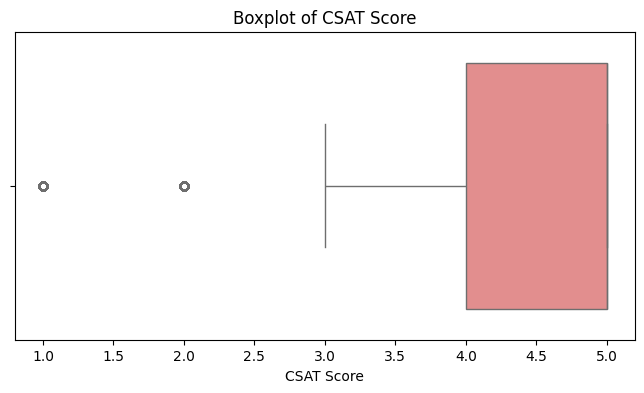

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()


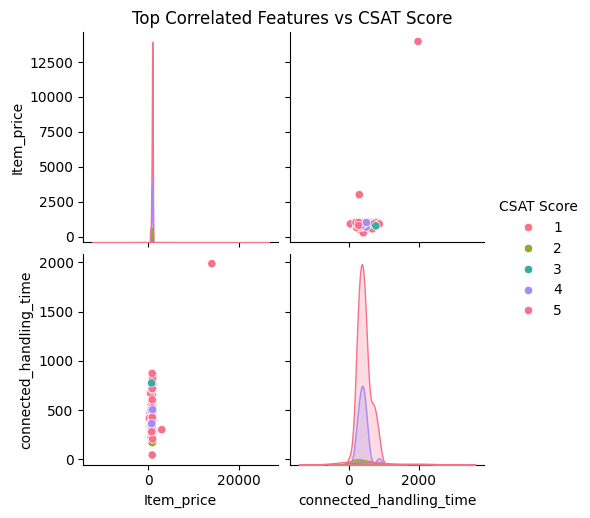

In [ ]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# 1. Copy dataset for plotting
df_plot = df.copy()

# 2. Encode CSAT Score if needed
if df_plot['CSAT Score'].dtype == 'object':
    le = LabelEncoder()
    df_plot['CSAT Score'] = le.fit_transform(df_plot['CSAT Score'])

# 3. Drop rows with missing values in CSAT Score or numeric columns
df_plot = df_plot.dropna(subset=['CSAT Score'])

# 4. Get numeric columns only (excluding any non-numeric)
numeric_df = df_plot.select_dtypes(include=['int64', 'float64'])

# 5. Ensure 'CSAT Score' is numeric and 1D
if 'CSAT Score' not in numeric_df.columns:
    numeric_df['CSAT Score'] = df_plot['CSAT Score']

# 6. Correlation with CSAT Score
correlations = numeric_df.corr()['CSAT Score'].drop('CSAT Score', errors='ignore')
top_corr_features = correlations.abs().sort_values(ascending=False).head(5).index.tolist()

# 7. Prepare final DataFrame for pairplot
pairplot_df = df_plot[top_corr_features + ['CSAT Score']].dropna()

# 8. Confirm all columns are 1D and numeric
assert all(pairplot_df[col].ndim == 1 for col in pairplot_df.columns), "One or more columns are not 1D!"

# 9. Plot
sns.pairplot(pairplot_df, hue='CSAT Score', palette='husl')
plt.suptitle("Top Correlated Features vs CSAT Score", y=1.02)
plt.show()


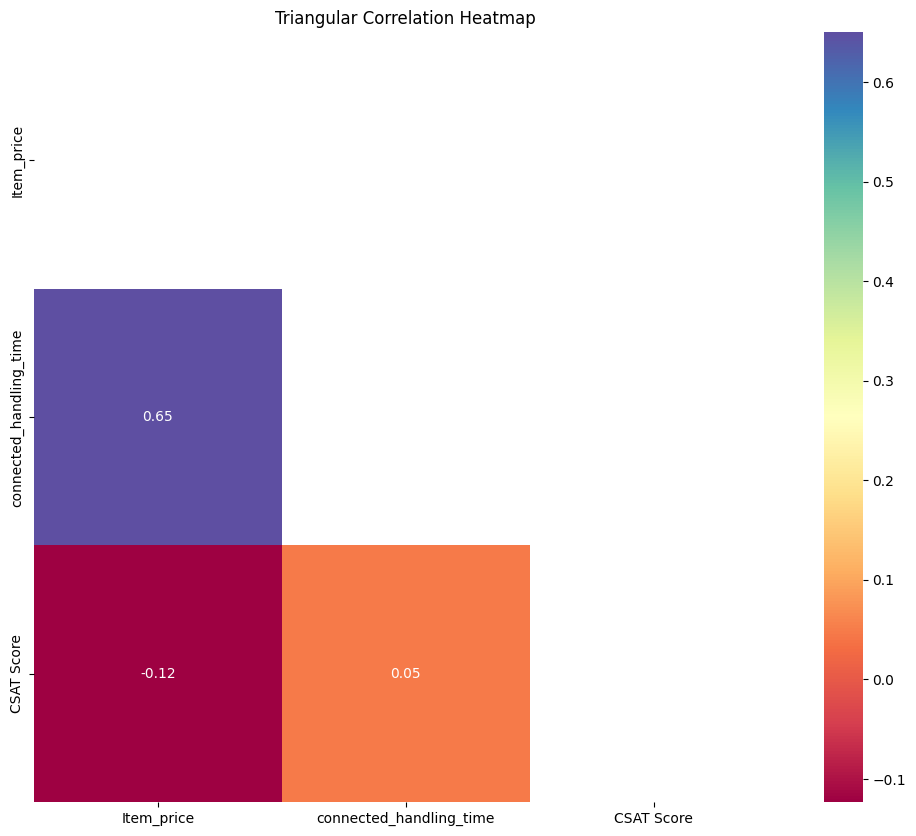

In [ ]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt=".2f", cmap='Spectral')
plt.title("Triangular Correlation Heatmap")
plt.show()


In [ ]:
# Drop the target column before VIF check
X_temp = df[numeric_cols].drop(columns=['CSAT Score'], errors='ignore').dropna()

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X_temp.columns
vif_data['VIF'] = [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]
print(vif_data)


                   Feature       VIF
0               Item_price  2.592346
1  connected_handling_time  2.592346


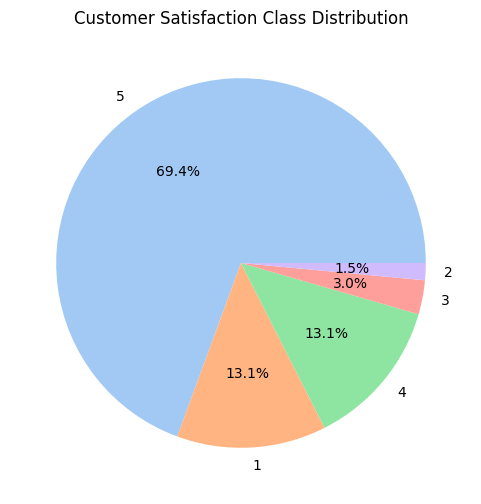

In [ ]:
plt.figure(figsize=(6, 6))
df['CSAT Score'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title("Customer Satisfaction Class Distribution")
plt.ylabel('')
plt.show()


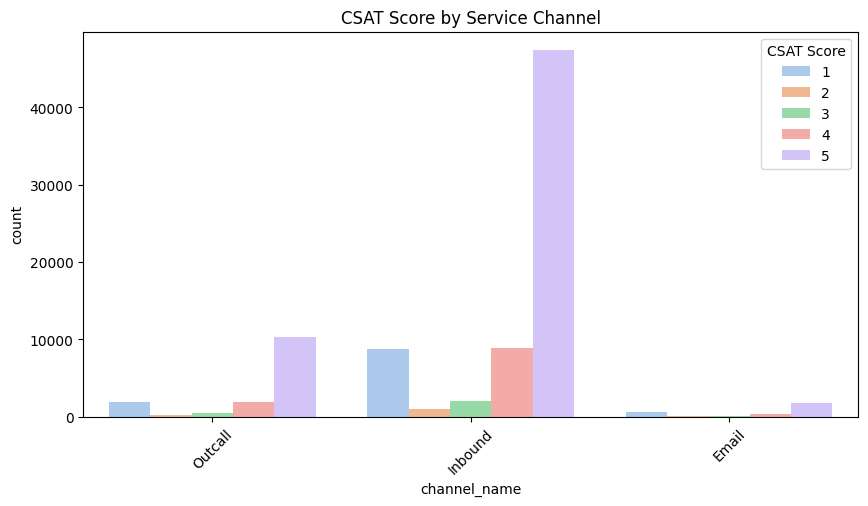

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='channel_name', hue='CSAT Score', palette='pastel')
plt.title("CSAT Score by Service Channel")
plt.xticks(rotation=45)
plt.show()


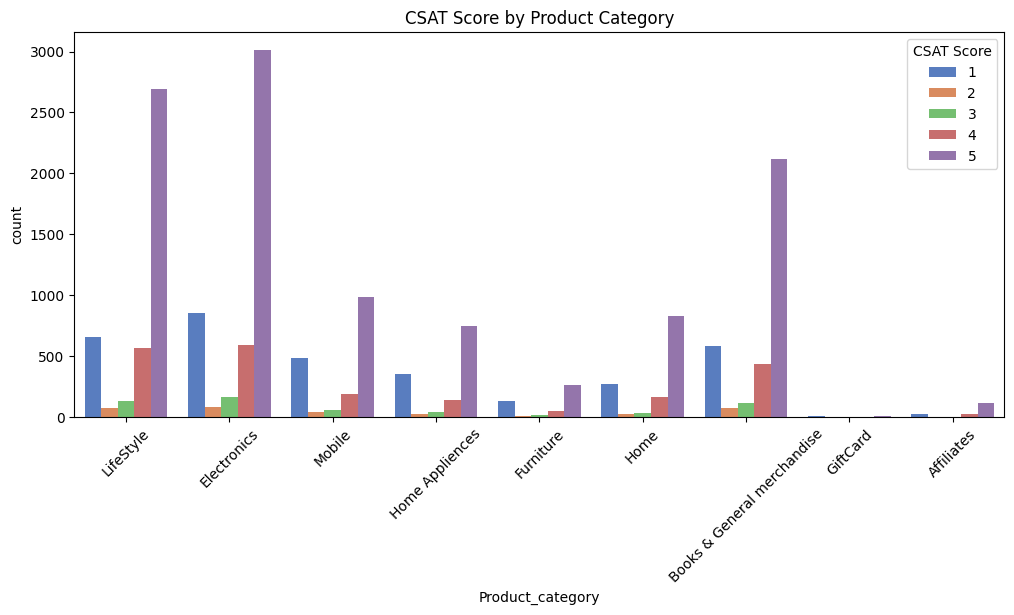

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Product_category', hue='CSAT Score', palette='muted')
plt.title("CSAT Score by Product Category")
plt.xticks(rotation=45)
plt.show()


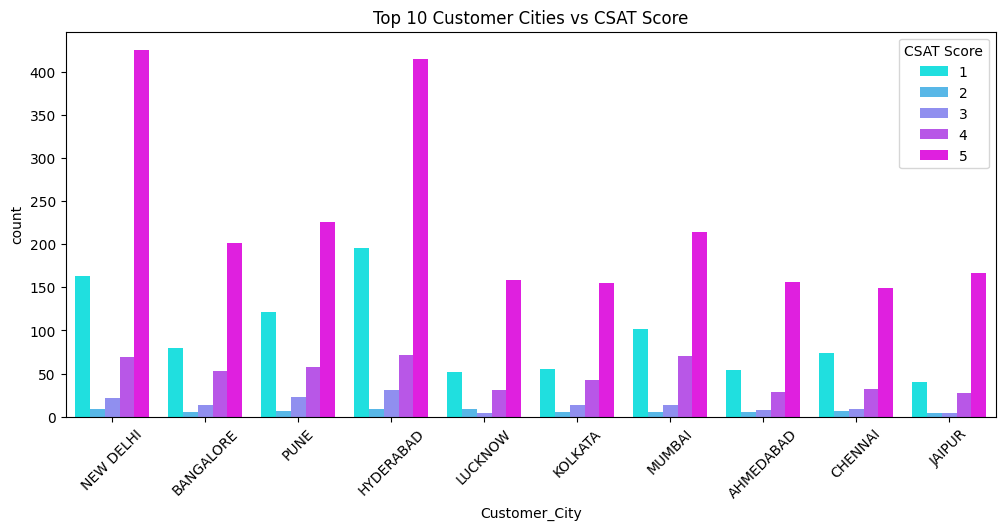

In [ ]:
top_cities = df['Customer_City'].value_counts().nlargest(10).index
plt.figure(figsize=(12, 5))
sns.countplot(data=df[df['Customer_City'].isin(top_cities)],
              x='Customer_City', hue='CSAT Score', palette='cool')
plt.title("Top 10 Customer Cities vs CSAT Score")
plt.xticks(rotation=45)
plt.show()


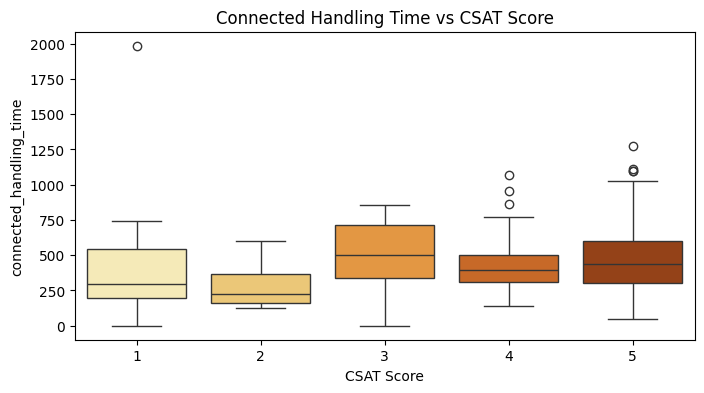

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='CSAT Score', y='connected_handling_time', palette='YlOrBr')
plt.title("Connected Handling Time vs CSAT Score")
plt.show()


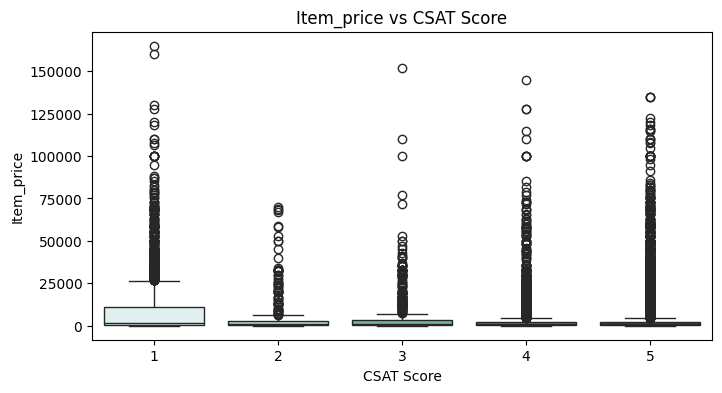

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='CSAT Score', y='Item_price', palette='BuGn')
plt.title("Item_price vs CSAT Score")
plt.show()


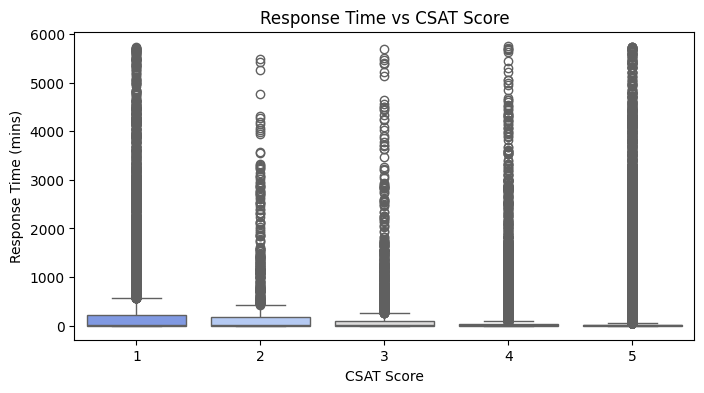

    Issue_reported at     issue_responded  Response Time (mins)
0 2023-08-01 11:13:00 2023-08-01 11:47:00                  34.0
1 2023-08-01 12:52:00 2023-08-01 12:54:00                   2.0
2 2023-08-01 20:16:00 2023-08-01 20:38:00                  22.0
3 2023-08-01 20:56:00 2023-08-01 21:16:00                  20.0
4 2023-08-01 10:30:00 2023-08-01 10:32:00                   2.0


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert with correct format assumption
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], dayfirst=True, errors='coerce')
df['issue_responded'] = pd.to_datetime(df['issue_responded'], dayfirst=True, errors='coerce')

# Create Response Time column in minutes
df['Response Time (mins)'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60

# Drop invalid or missing response time values
df = df[df['Response Time (mins)'].notnull() & (df['Response Time (mins)'] >= 0)]

# Plot
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='CSAT Score', y='Response Time (mins)', palette='coolwarm')
plt.title("Response Time vs CSAT Score")
plt.show()
print(df[['Issue_reported at', 'issue_responded', 'Response Time (mins)']].head())


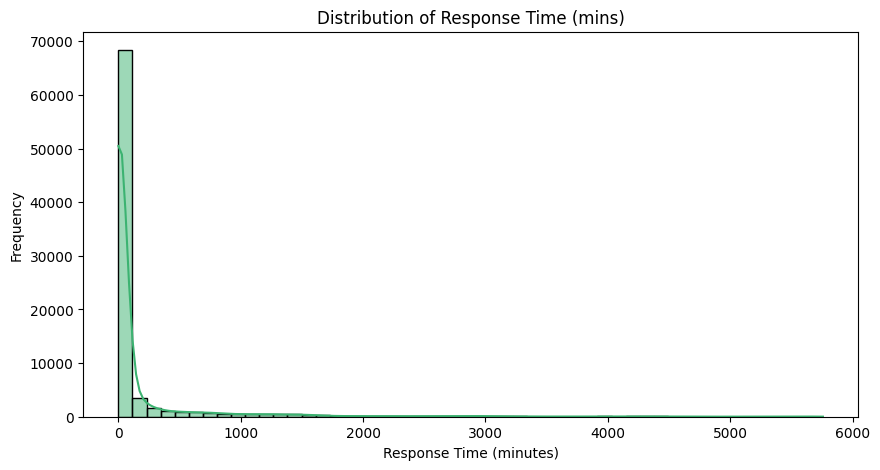

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Response Time (mins)'], bins=50, kde=True, color='mediumseagreen')
plt.title("Distribution of Response Time (mins)")
plt.xlabel("Response Time (minutes)")
plt.ylabel("Frequency")
plt.show()


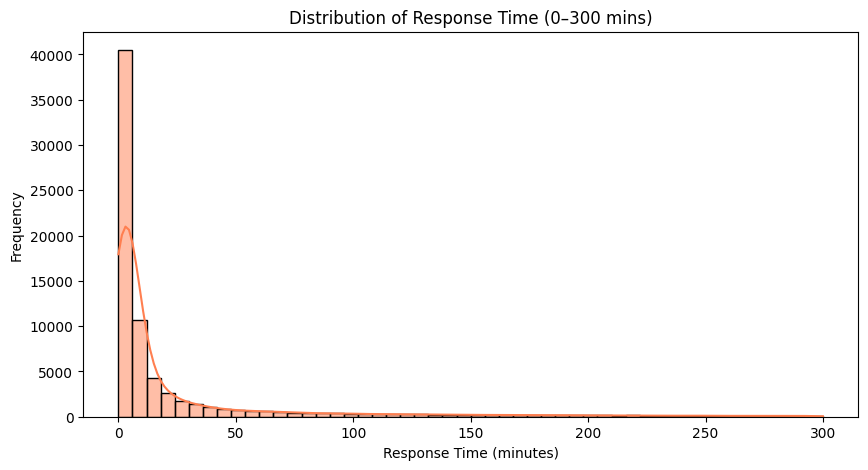

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Response Time (mins)'] <= 300]['Response Time (mins)'], bins=50, kde=True, color='coral')
plt.title("Distribution of Response Time (0–300 mins)")
plt.xlabel("Response Time (minutes)")
plt.ylabel("Frequency")
plt.show()


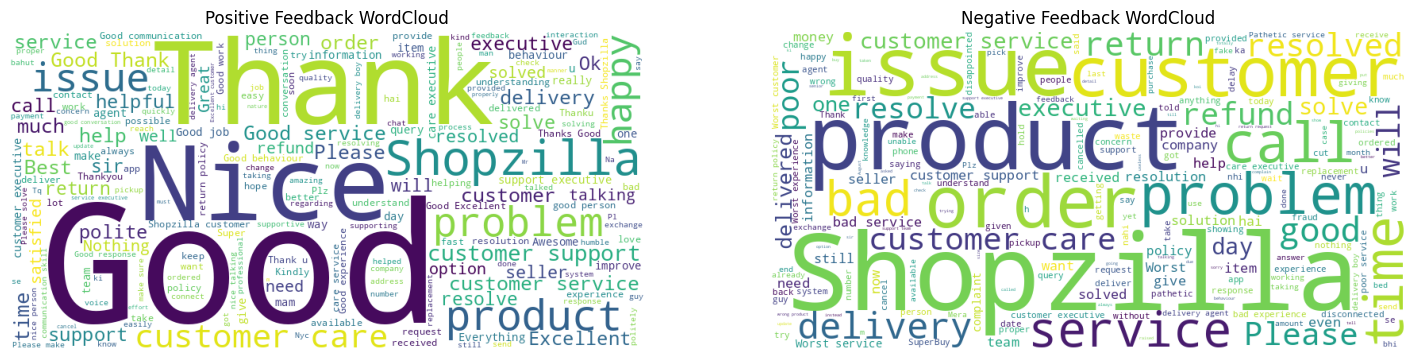

In [ ]:
from wordcloud import WordCloud
from collections import Counter

positive = " ".join(df[df['CSAT Score'] == df['CSAT Score'].max()]['Customer Remarks'].dropna())
negative = " ".join(df[df['CSAT Score'] == df['CSAT Score'].min()]['Customer Remarks'].dropna())

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(WordCloud(width=800, height=400, background_color='white').generate(positive))
ax[0].set_title('Positive Feedback WordCloud')
ax[0].axis('off')

ax[1].imshow(WordCloud(width=800, height=400, background_color='white').generate(negative))
ax[1].set_title('Negative Feedback WordCloud')
ax[1].axis('off')
plt.show()


In [ ]:
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 15.8 MB/s eta 0:00:00


In [ ]:
!pip install imbalanced-learn


# **Data Preparation, Optimization, and Model Development Pipeline**

This section consolidates the complete preprocessing and modeling pipeline, including feature engineering, data splitting, class balancing via SMOTE, feature scaling, hyperparameter tuning with Optuna, and final model training across multiple algorithms.

In [ ]:
# 🛠️ Install missing packages (only needed in Colab)
!pip install -q optuna imbalanced-learn

# 📦 Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
import warnings
warnings.filterwarnings("ignore")

# ---------- 🎯 Target Fix ----------
df['CSAT Score'] = df['CSAT Score'] - 1  # Normalize labels to 0–4

# ---------- 🧠 Feature Engineering ----------
df['order_date_time'] = pd.to_datetime(df['order_date_time'])
df['order_hour'] = df['order_date_time'].dt.hour
df['order_day'] = df['order_date_time'].dt.day
df['order_month'] = df['order_date_time'].dt.month
df['weekend_order'] = df['order_date_time'].dt.weekday >= 5

# Cyclical Encoding for 'hour'
df['order_hour_sin'] = np.sin(2 * np.pi * df['order_hour'] / 24)
df['order_hour_cos'] = np.cos(2 * np.pi * df['order_hour'] / 24)

# Log transform
df['Item_price_log'] = np.log1p(df['Item_price'])
df['handling_price_ratio'] = df['connected_handling_time'] / (df['Item_price'] + 1)

# Drop non-useful columns
drop_cols = ['order_date_time', 'order_hour', 'Item_price']
df.drop(columns=drop_cols, inplace=True)

# Encode categoricals
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# ✅ Handle Missing Values
imputer = SimpleImputer(strategy='mean')  # You can use median or most_frequent too
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# Split features and target
X = df_imputed.drop('CSAT Score', axis=1)
y = df_imputed['CSAT Score']

# ---------- 🧪 Train/Test Split ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# ---------- ⚖️ Balance with SMOTE ----------
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

# ---------- 🔍 Scale ----------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------- 🧪 Optuna Optimization Function ----------
def tune_model(trial, model_name):
    if model_name == "RandomForest":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            max_depth=trial.suggest_int("max_depth", 10, 50),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 4),
            random_state=42, n_jobs=-1)

    elif model_name == "XGBoost":
        model = XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
            objective='multi:softmax', num_class=5, eval_metric='mlogloss',
            use_label_encoder=False, random_state=42, n_jobs=-1)

    elif model_name == "LightGBM":
        model = LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            num_leaves=trial.suggest_int("num_leaves", 20, 128),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 20, 100),
            feature_fraction=trial.suggest_float("feature_fraction", 0.6, 1.0),
            objective='multiclass', num_class=5, random_state=42, n_jobs=-1)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

# ---------- 🧪 Tune & Train Models ----------
models = ["RandomForest", "XGBoost", "LightGBM"]
best_models = {}

for name in models:
    print(f"\n🔍 Tuning {name}...")
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: tune_model(trial, name), n_trials=30)

    print(f"✅ Best Params for {name}: {study.best_params}")

    # Train final model
    if name == "RandomForest":
        best_models[name] = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
    elif name == "XGBoost":
        best_models[name] = XGBClassifier(**study.best_params, objective='multi:softmax', num_class=5,
                                          use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        best_models[name] = LGBMClassifier(**study.best_params, objective='multiclass', num_class=5,
                                           random_state=42, n_jobs=-1)

    best_models[name].fit(X_train, y_train)
    preds = best_models[name].predict(X_test)

    acc = accuracy_score(y_test, preds)
    print(f"✅ Final Accuracy for {name}: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, preds))


[I 2025-05-04 18:25:14,978] A new study created in memory with name: no-name-ca620ff5-c231-4a1f-ac0b-58021e82c582



🔍 Tuning RandomForest...


[I 2025-05-04 18:29:55,273] Trial 0 finished with value: 0.6862414154347573 and parameters: {'n_estimators': 238, 'max_depth': 24, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.6862414154347573.
[I 2025-05-04 18:32:57,032] Trial 1 finished with value: 0.6810615760679781 and parameters: {'n_estimators': 177, 'max_depth': 17, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6862414154347573.
[I 2025-05-04 18:37:39,848] Trial 2 finished with value: 0.6830403911069725 and parameters: {'n_estimators': 215, 'max_depth': 41, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.6862414154347573.
[I 2025-05-04 18:41:36,260] Trial 3 finished with value: 0.6869398207426376 and parameters: {'n_estimators': 191, 'max_depth': 50, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.6869398207426376.
[I 2025-05-04 18:45:53,796] Trial 4 finished with value: 0.6829239902223256 and parameters: {'n_estimators': 197, 'max_depth': 49, 'min_samples_leaf': 1}. Best is trial 3 with value: 0.686

✅ Best Params for RandomForest: {'n_estimators': 154, 'max_depth': 40, 'min_samples_leaf': 2}


[I 2025-05-04 20:15:39,067] A new study created in memory with name: no-name-16a5bd57-eff0-4328-89a9-fda59753d707


...

[LightGBM] [Warning] min_data_in_leaf is set=49, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=49
[LightGBM] [Warning] feature_fraction is set=0.6325510326436741, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6325510326436741
[LightGBM] [Warning] min_data_in_leaf is set=49, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=49
[LightGBM] [Warning] feature_fraction is set=0.6325510326436741, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6325510326436741
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088560 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5917
[LightGBM] [Info] Number of data points in the train set: 238465, number of used features: 24
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from sc

[I 2025-05-04 21:12:48,239] Trial 28 finished with value: 0.704225352112676 and parameters: {'n_estimators': 281, 'num_leaves': 69, 'learning_rate': 0.043982441477066564, 'min_data_in_leaf': 49, 'feature_fraction': 0.6325510326436741}. Best is trial 17 with value: 0.7048073565359096.


[LightGBM] [Warning] min_data_in_leaf is set=55, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=55
[LightGBM] [Warning] feature_fraction is set=0.6896162854608017, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6896162854608017
[LightGBM] [Warning] min_data_in_leaf is set=55, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=55
[LightGBM] [Warning] feature_fraction is set=0.6896162854608017, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6896162854608017
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.063015 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5917
[LightGBM] [Info] Number of data points in the train set: 238465, number of used features: 24
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609

[I 2025-05-04 21:13:56,709] Trial 29 finished with value: 0.696659294610639 and parameters: {'n_estimators': 237, 'num_leaves': 97, 'learning_rate': 0.01340403386526124, 'min_data_in_leaf': 55, 'feature_fraction': 0.6896162854608017}. Best is trial 17 with value: 0.7048073565359096.


✅ Best Params for LightGBM: {'n_estimators': 262, 'num_leaves': 57, 'learning_rate': 0.04501942563334999, 'min_data_in_leaf': 20, 'feature_fraction': 0.6444544860750508}
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.6444544860750508, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6444544860750508
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.6444544860750508, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6444544860750508
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060796 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5917
[LightGBM] [Info] Number of data points in the train set: 238465, number of used f

**Install Required Packages**

1. Installs third-party libraries not pre-included in Google Colab. Specifically, Optuna for hyperparameter optimization and imbalanced-learn for handling class imbalance using SMOTE.
2. Ensures a reproducible and portable environment across machines.

**Import Dependencies**

1. Imports all essential libraries for data manipulation (pandas, numpy), model building (sklearn, xgboost, lightgbm), preprocessing, and evaluation.
2. Centralizing imports improves maintainability and clarity.

**Target Normalization**

1. Shifts the CSAT Score from a 1–5 range to 0–4 to align with classification model requirements and avoid off-by-one errors in multiclass handling.
2. Maintains consistency across model training and evaluation.

**Feature Engineering**

1. Extracts temporal features (hour, day, month) and encodes cyclical patterns using sine and cosine transformations. Adds derived features such as log-transformed price and operational ratios.
2. Transforms raw timestamps into informative predictors and stabilizes skewed distributions.

 **Drop Redundant Features**

1. Removes columns that have been transformed or provide little additional value (e.g., original timestamp, raw price).
2. Reduces dimensionality and minimizes feature redundancy.

**Categorical Encoding**

1. Encodes categorical variables using LabelEncoder to convert string types into numeric values compatible with scikit-learn-based models.
2. Prepares data for modeling while preserving class labels.

**Missing Value Imputation**

1. Applies mean imputation to fill missing values using SimpleImputer, ensuring that models can train without error.
2. Retains all rows without introducing significant bias.

**Train-Test Split**

1. Splits the dataset into training and testing subsets using stratification to preserve class proportions.
2. Enables robust evaluation of model generalization.

**Address Class Imbalance (SMOTE)**

1. Applies SMOTE to synthetically balance the training dataset, particularly important in multiclass classification problems with skewed labels.
2. Improves model fairness and recall on underrepresented classes.

**Feature Scaling**

1. Standardizes features using StandardScaler to normalize input distributions.
2. Beneficial for distance-based and tree-based ensemble models to ensure stable gradient updates.

**Define Optuna Optimization Function**

1. Encapsulates model-specific hyperparameter spaces into a function compatible with Optuna’s optimization process.
2. Enables scalable, automated hyperparameter search across different algorithms.

**Hyperparameter Tuning and Model Training**

1. Uses Optuna to tune Random Forest, XGBoost, and LightGBM classifiers, followed by training each model with the best-found parameters.
2. Maximizes predictive performance through efficient search and model selection.

**Model Evaluation**

1. Evaluates model performance on the test set using accuracy and detailed classification metrics (precision, recall, F1-score).
2. Provides a comprehensive view of how well each model performs across all CSAT levels.

# **Model Evaluation and Optimization Summary**

This section presents the optimization history, confusion matrix, feature importance, and ensembling results for each model. These visualizations and techniques collectively help assess model tuning, classification performance, key predictive features, and the benefits of combining models.



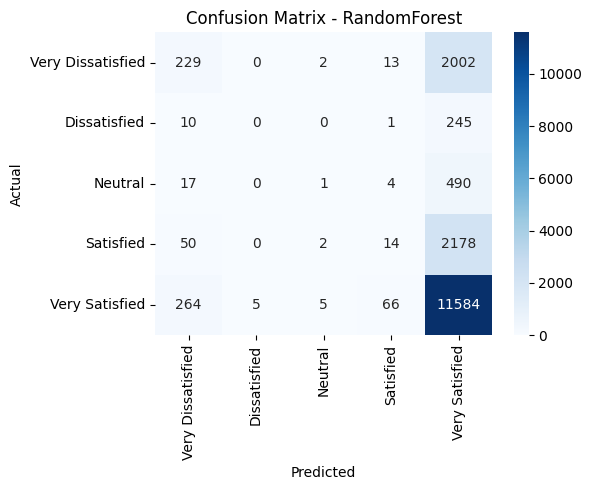

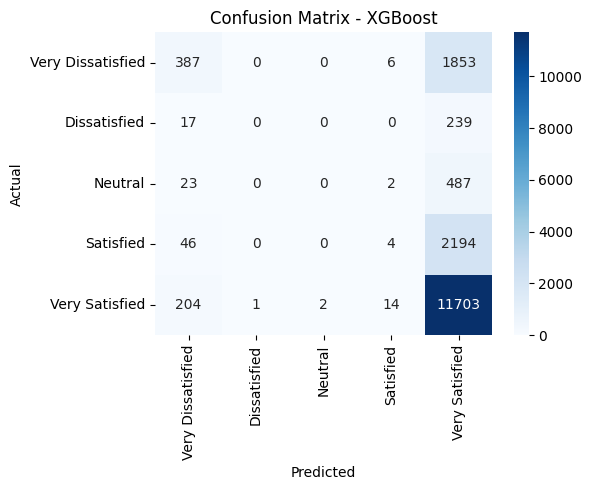

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.6444544860750508, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6444544860750508


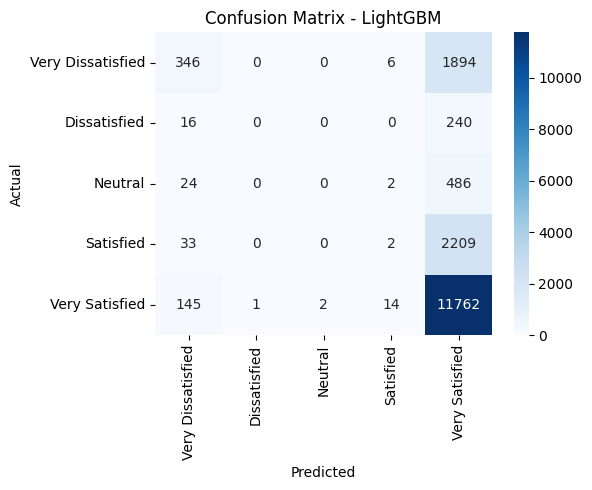

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Class labels
class_names = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']

# Plot Confusion Matrix
def plot_confusion(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Plot for each model
for name, model in best_models.items():
    preds = model.predict(X_test)
    plot_confusion(name, y_test, preds)


In [ ]:
import optuna.visualization as vis

# Visualize optimization history
for name in models:
    print(f"📈 Optimization History for {name}")
    vis.plot_optimization_history(study).show()


📈 Optimization History for RandomForest


📈 Optimization History for XGBoost


📈 Optimization History for LightGBM


# **Insight**

1. The optimization history for the **RandomForest model** shows that most of the performance improvement occurred within the first 8 trials. After that, the best score remained mostly stable, indicating that the model's optimal hyperparameters were found early and later trials provided only minor or no improvements. This suggests the tuning process was **efficient** and reached a **good solution** quickly.
2. The optimization history plot for the **XGBoost model** shows that the best objective value steadily improved during the initial trials and then plateaued, indicating **convergence** and **diminishing returns** from further hyperparameter tuning.
3. The optimization history for the **LightGBM model** similarly shows early gains in objective value followed by a plateau, suggesting that **optimal** hyperparameters were found within the **first 10–15 trials**.

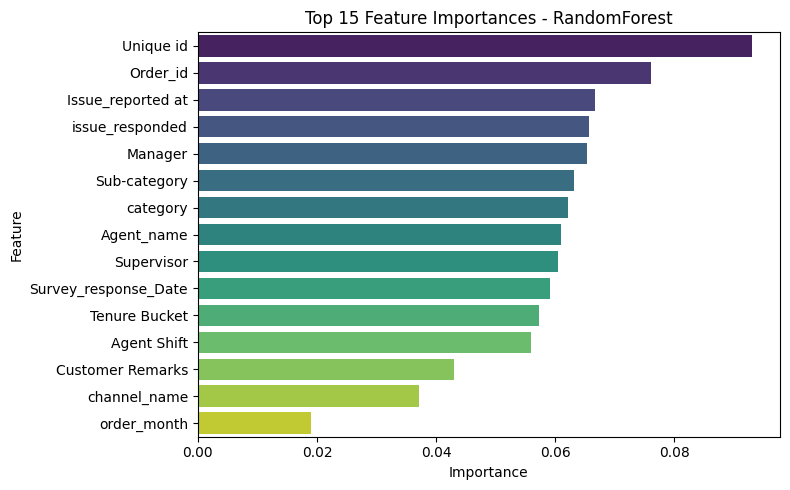

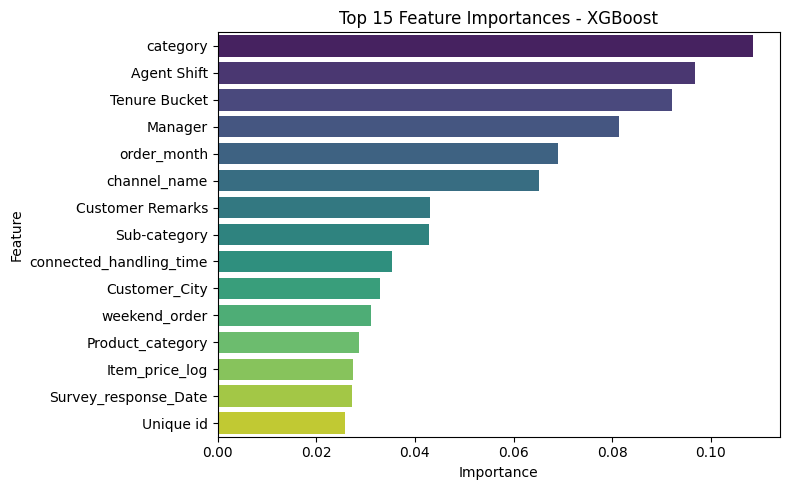

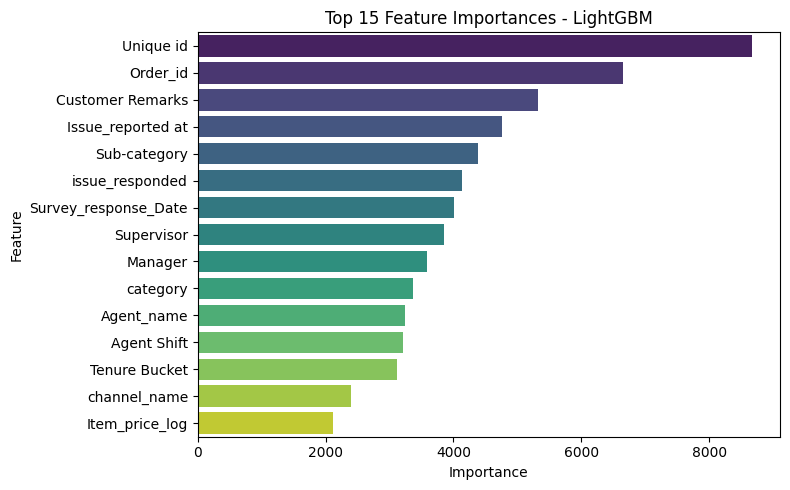

In [ ]:
importances_df = {}

def plot_feature_importance(model, model_name, feature_names):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False).head(15)
        importances_df[model_name] = df

        plt.figure(figsize=(8, 5))
        sns.barplot(x='Importance', y='Feature', data=df, palette='viridis')
        plt.title(f'Top 15 Feature Importances - {model_name}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"{model_name} does not support feature_importances_")

# Feature names used after imputation
feature_names = X.columns

# Plot for each model
for name, model in best_models.items():
    plot_feature_importance(model, name, feature_names)


# **Insights**

**1. Overemphasis on Identifier Features in Tree Models**

Both RandomForest and LightGBM rank Unique_id and Order_id as top features. These identifiers are unlikely to have predictive power for customer satisfaction and may cause overfitting. It's advisable to exclude or anonymize such features unless they encode meaningful sequence or grouping.

**2. Consistent High-Value Operational Features**

Features like Manager, Agent Shift, Tenure Bucket, and category appear among the top 15 across all models, highlighting their genuine influence on satisfaction. These variables represent agent experience, shift patterns, and product categorization—key operational drivers in customer service.

**3. Model-Specific Variations Reflect Different Learning Behaviors**

XGBoost emphasizes generalized, interpretable features (category, Agent Shift, Tenure Bucket) with less weight on IDs, suggesting robustness.

LightGBM behaves similarly to RandomForest in emphasizing identifiers but also includes text-derived features like Customer Remarks.
This variation suggests value in ensemble modeling or feature importance averaging to ensure balanced, bias-mitigated predictions.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# best_models = {'RandomForest': rf_model, 'XGBoost': xgb_model, 'LightGBM': lgb_model}

# Create soft voting ensemble using the top models
voting_clf = VotingClassifier(
    estimators=[
        ('rf', best_models['RandomForest']),
        ('xgb', best_models['XGBoost']),
        ('lgb', best_models['LightGBM'])
    ],
    voting='soft'  #
)

# Train ensemble on training data
voting_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = voting_clf.predict(X_test)

# Evaluation
print("Ensemble Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.6444544860750508, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6444544860750508
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.6444544860750508, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6444544860750508
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.095888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5917
[LightGBM] [Info] Number of data points in the train set: 238465, number of used features: 24
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609

**Key Insights**

1. Class Imbalance

  The model performs well on class 4.0 (majority class), with 99% recall and 82% F1-score, but struggles with all other classes, showing near-zero metrics.

2. Low Performance on Minority Classes

   Classes 0.0 to 3.0 are misclassified as class 4.0, resulting in poor macro and weighted average scores.

3. Recommendation

   Apply SMOTE, class weights, or data resampling to address the imbalance and improve minority class prediction.

# **Saving the Model**

In [ ]:
import joblib

# Saving the trained ensemble model to a file
joblib.dump(voting_clf, 'ensemble_model.pkl')

print("Ensemble model saved as 'ensemble_model.pkl'")


Ensemble model saved as 'ensemble_model.pkl'
